#mobile prize classsification project



we will try to predict the class of prices of a mobile phone based on its features 

#Machine learning

1.Problem defination
2. data analysis 
     1. EDA
     2. data evaluation
     3. Features

3. ML algorithm

    1. Model selection
    2. model training
    3. model evaluation
    4. model comparison
    5. model hyperparameter- tuning
    6. feature importance
    7. cross validation
    8. reporting / summarizing


4. Experimentation


## Problem defination

solve this problem he collects sales data of mobile phones of various companies.

Bob wants to find out some relation between features of a mobile phone(eg:- RAM,Internal Memory etc) and its selling price. 

in this problem you do not have to predict actual price but a price range indicating how high the price is

supposed to predict the class of cell phone prices

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
train_data= pd.read_csv('DATA/train.csv')
train_data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,14,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,3,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,3,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,5,336,670,869,18,10,19,1,1,1,0


In [6]:
test_data=pd.read_csv('DATA/test.csv')
test_data

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,3,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,5,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,3,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,8,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,6,18,749,810,1773,15,8,7,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,1700,1,1.9,0,0,1,54,0.5,170,7,17,644,913,2121,14,8,15,1,1,0
996,997,609,0,1.8,1,0,0,13,0.9,186,4,2,1152,1632,1933,8,1,19,0,1,1
997,998,1185,0,1.4,0,1,1,8,0.5,80,1,12,477,825,1223,5,0,14,1,0,0
998,999,1533,1,0.5,1,0,0,50,0.4,171,2,12,38,832,2509,15,11,6,0,1,0


In [7]:
ser= pd.Series([1,2,3,4,5])
ser

0    1
1    2
2    3
3    4
4    5
dtype: int64

In [8]:
dat= pd.DataFrame([[1,2,3,4,5],[6,7,2,3,5]])
dat

,0,1,2,3,4
0,1,2,3,4,5
1,6,7,2,3,5


# EDA

In [9]:
train_data.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


In [10]:
train_data.tail()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,14,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,3,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,3,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,5,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,16,483,754,3919,19,4,2,1,1,1,3


In [11]:
train_data.price_range

0       1
1       2
2       2
3       2
4       1
       ..
1995    0
1996    2
1997    3
1998    0
1999    3
Name: price_range, Length: 2000, dtype: int64

In [ ]:
train_data ["price range"]   #this would be written if column name did not have underscore

In [14]:
train_data.price_range.value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [15]:
train_data.price_range.value_counts(normalize=True)

price_range
1    0.25
2    0.25
3    0.25
0    0.25
Name: proportion, dtype: float64

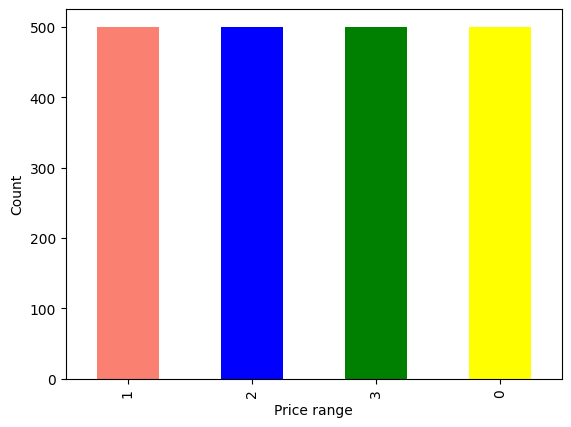

In [ ]:
train_data.price_range.value_counts().plot(
    kind= 'bar' ,color=['salmon','blue','green','yellow'],xlabel='Price range',ylabel='Count'

);

In [ ]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [ ]:
train_data.isna().sum()   # this shows how many missing values we have

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [ ]:
train_data.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [ ]:
pd.crosstab(index=train_data.blue, columns=train_data.price_range)

price_range,0,1,2,3
blue,,,,
0,257,255,257,241
1,243,245,243,259


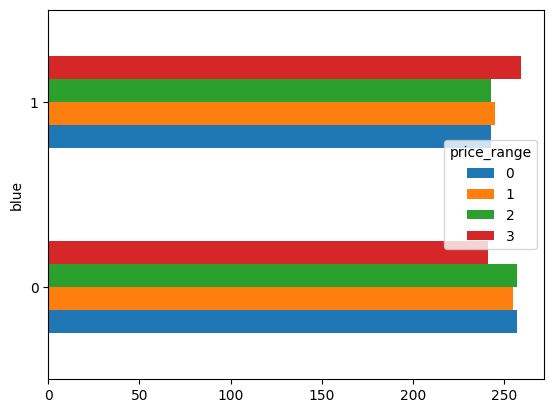

In [ ]:
pd.crosstab(index=train_data.blue, columns=train_data.price_range).plot(kind='barh');

In [ ]:
pd.crosstab(index=train_data.dual_sim, columns=train_data.price_range)

price_range,0,1,2,3
dual_sim,,,,
0,250,245,251,235
1,250,255,249,265


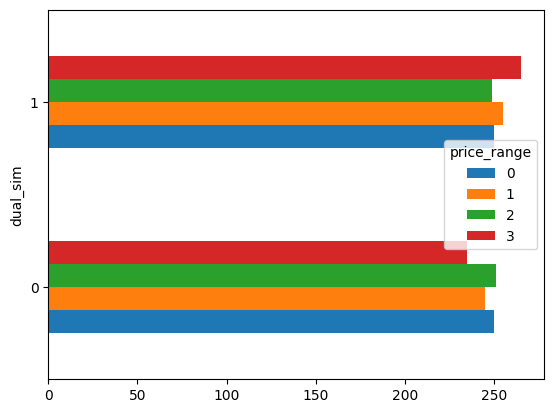

In [ ]:
pd.crosstab(index=train_data.dual_sim, columns=train_data.price_range).plot(kind='barh');

<Axes: ylabel='Frequency'>

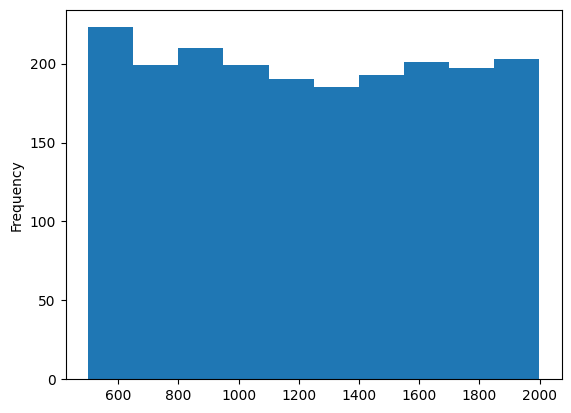

In [ ]:
train_data.battery_power.plot.hist()

<Axes: ylabel='Frequency'>

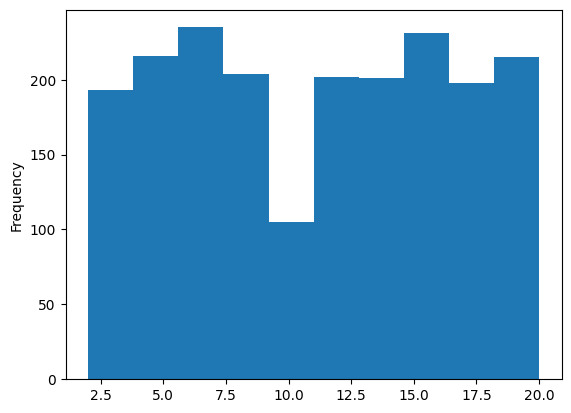

In [ ]:
train_data.talk_time.plot.hist()

In [ ]:
corr_matrix= train_data.corr()    #.corr() computes the correlation matrix between all numeric columns.
corr_matrix                                 #What do the values mean?
                                     # +1 → Perfect positive correlation (both increase together).
                                      # 0 → No linear correlation.
                                    #−1 → Perfect negative correlation (one increases, the other decreases).    

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
battery_power,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004004,0.034085,0.001844,-0.029727,...,0.014901,-0.008402,-0.000653,-0.029959,-0.021421,0.052510,0.011522,-0.010516,-0.008343,0.200723
blue,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041177,0.004049,-0.008605,0.036161,...,-0.006872,-0.041533,0.026351,-0.002952,0.000613,0.013934,-0.030236,0.010061,-0.021863,0.020573
clock_speed,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006545,-0.014364,0.012350,-0.005724,...,-0.014523,-0.009476,0.003443,-0.029078,-0.007378,-0.011432,-0.046433,0.019756,-0.024471,-0.006606
dual_sim,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015679,-0.022142,-0.008979,-0.024658,...,-0.020875,0.014291,0.041072,-0.011949,-0.016666,-0.039404,-0.014008,-0.017117,0.022740,0.017444
fc,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.029133,-0.001791,0.023618,-0.013356,...,-0.009990,-0.005176,0.015099,-0.011014,-0.012373,-0.006829,0.001793,-0.014828,0.020085,0.021998
four_g,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008690,-0.001823,-0.016537,-0.029706,...,-0.019236,0.007448,0.007313,0.027166,0.037005,-0.046628,0.584246,0.016758,-0.017620,0.014772
int_memory,-0.004004,0.041177,0.006545,-0.015679,-0.029133,0.008690,1.000000,0.006886,-0.034214,-0.028310,...,0.010441,-0.008335,0.032813,0.037771,0.011731,-0.002790,-0.009366,-0.026999,0.006993,0.044435
m_dep,0.034085,0.004049,-0.014364,-0.022142,-0.001791,-0.001823,0.006886,1.000000,0.021756,-0.003504,...,0.025263,0.023566,-0.009434,-0.025348,-0.018388,0.017003,-0.012065,-0.002638,-0.028353,0.000853
mobile_wt,0.001844,-0.008605,0.012350,-0.008979,0.023618,-0.016537,-0.034214,0.021756,1.000000,-0.018989,...,0.000939,0.000090,-0.002581,-0.033855,-0.020761,0.006209,0.001551,-0.014368,-0.000409,-0.030302
n_cores,-0.029727,0.036161,-0.005724,-0.024658,-0.013356,-0.029706,-0.028310,-0.003504,-0.018989,1.000000,...,-0.006872,0.024480,0.004868,-0.000315,0.025826,0.013148,-0.014733,0.023774,-0.009964,0.004399


<Axes: >

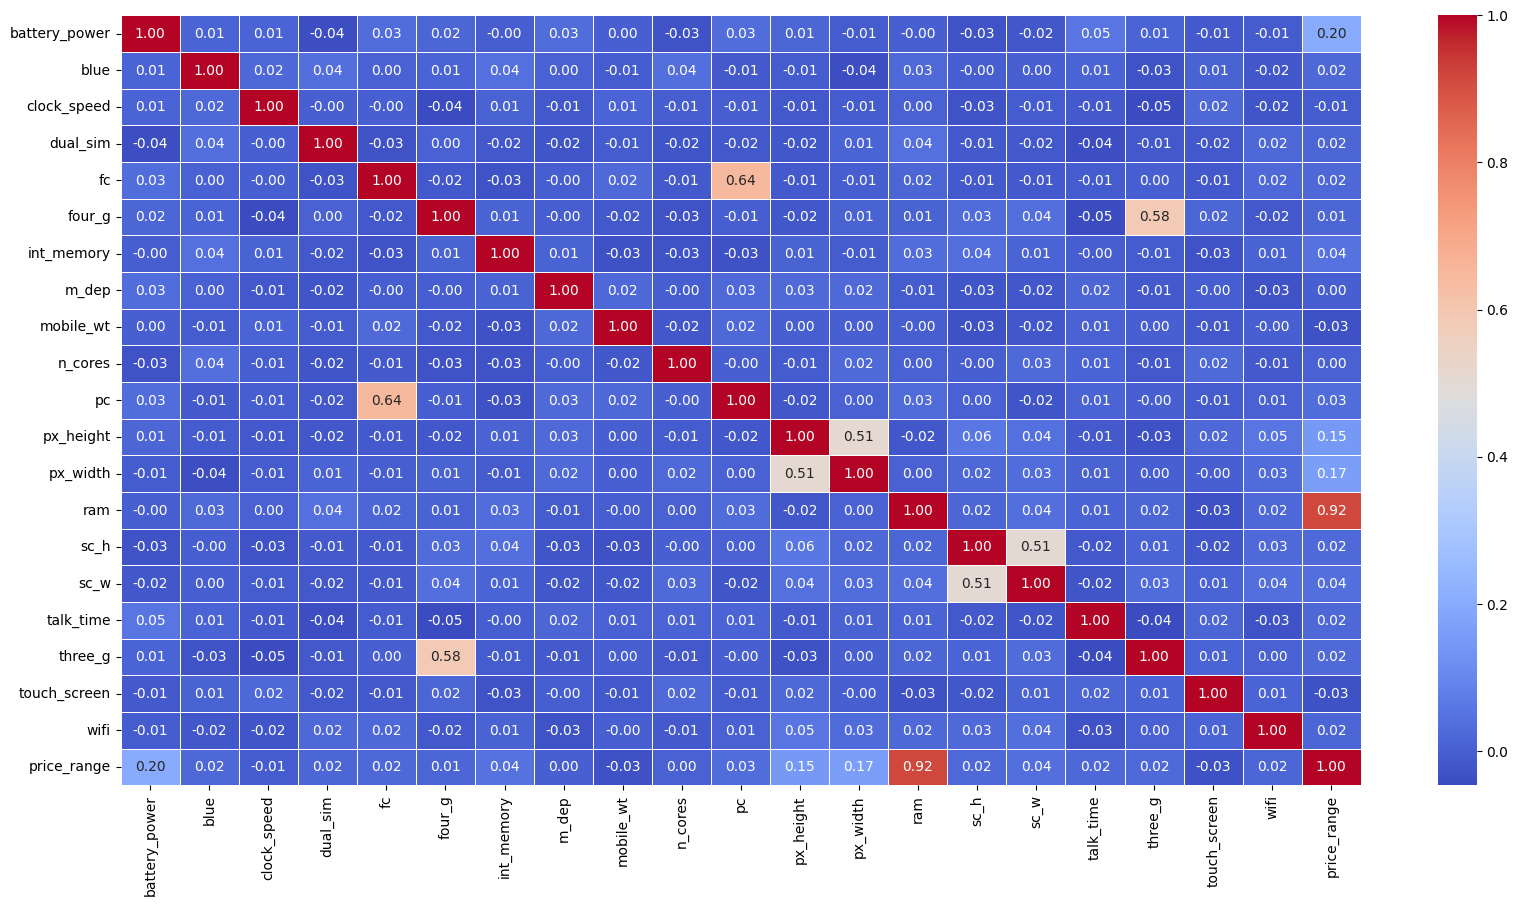

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix,
annot=True, linewidth=0.5,fmt='.2f',cmap='coolwarm')


In [ ]:
X_train=train_data.drop('price_range',axis=1)  #axis=0 → Search the row names (index).
                                                 #axis=1 → Search the column names.  
                                                   # Look along the columns (axis=1). Is there a column named price_range?"Yes!
y_train= train_data.price_range
(X_train,y_train)

(      battery_power  blue  clock_speed  ...  three_g  touch_screen  wifi
 0               842     0          2.2  ...        0             0     1
 1              1021     1          0.5  ...        1             1     0
 2               563     1          0.5  ...        1             1     0
 3               615     1          2.5  ...        1             0     0
 4              1821     1          1.2  ...        1             1     0
 ...             ...   ...          ...  ...      ...           ...   ...
 1995            794     1          0.5  ...        1             1     0
 1996           1965     1          2.6  ...        1             1     1
 1997           1911     0          0.9  ...        1             1     0
 1998           1512     0          0.9  ...        1             1     1
 1999            510     1          2.0  ...        1             1     1
 
 [2000 rows x 20 columns],
 0       1
 1       2
 2       2
 3       2
 4       1
        ..
 1995    0
 1996 

In [17]:
X_test=test_data.drop('id',axis=1)

X_test.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1043,1,1.8,1,14,0,5,0.1,193,3,16,226,1412,3476,12,7,2,0,1,0
1,841,1,0.5,1,4,1,61,0.8,191,5,12,746,857,3895,6,0,7,1,0,0
2,1807,1,2.8,0,1,0,27,0.9,186,3,4,1270,1366,2396,17,10,10,0,1,1
3,1546,0,0.5,1,18,1,25,0.5,96,8,20,295,1752,3893,10,0,7,1,1,0
4,1434,0,1.4,0,11,1,49,0.5,108,6,18,749,810,1773,15,8,7,1,0,1


In [18]:
X_test

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1043,1,1.8,1,14,0,5,0.1,193,3,16,226,1412,3476,12,7,2,0,1,0
1,841,1,0.5,1,4,1,61,0.8,191,5,12,746,857,3895,6,0,7,1,0,0
2,1807,1,2.8,0,1,0,27,0.9,186,3,4,1270,1366,2396,17,10,10,0,1,1
3,1546,0,0.5,1,18,1,25,0.5,96,8,20,295,1752,3893,10,0,7,1,1,0
4,1434,0,1.4,0,11,1,49,0.5,108,6,18,749,810,1773,15,8,7,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1700,1,1.9,0,0,1,54,0.5,170,7,17,644,913,2121,14,8,15,1,1,0
996,609,0,1.8,1,0,0,13,0.9,186,4,2,1152,1632,1933,8,1,19,0,1,1
997,1185,0,1.4,0,1,1,8,0.5,80,1,12,477,825,1223,5,0,14,1,0,0
998,1533,1,0.5,1,0,0,50,0.4,171,2,12,38,832,2509,15,11,6,0,1,0


## One Hot Encoding

one hot encoding is a methodology to convert string, objects or categories into numbers so our ML models can find patterns in the dataset

### one hot encoding will be performed on the car data so we can see how it functions

#### DATA 
#contains details of cars and their various features.
dataset is available on kaggle

In [4]:
#Loading dataset 
car_data = pd.read_csv("DATA/cardata.csv")
car_data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [5]:
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
# checking data types
car_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


so here 4 are str types , so need to convert it to numerical format

In [ ]:
X_car = car_data      # you are simply assigning the dataframe car_data to another variable named X_car
X_car.shape

(301, 9)

In [ ]:
# Turning the categories/objects into numbers 

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features= ["Car_Name","Fuel_Type","Seller_Type","Transmission"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([(
    "one_hot",  #It is simply a label/name given to that transformation inside ColumnTransformer.
    one_hot,     # actual encoder object
    categorical_features)],
    remainder='passthrough'

)

transformed_X= transformer.fit_transform(X_car)
transformed_X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2419 stored elements and shape (301, 110)>

fit() → learns the categories present in each categorical column.
transform() → converts those categories into numerical One-Hot Encoded columns (0s and 1s).

So, shortly:

fit_transform() learns the categories and converts them into numerical form internally. ✅

transformer.fit_transform(X_car) internally:

Finds all categories.
Creates separate columns for them.
Fills each column with:
1 → category is present (True)
0 → category is not present (False)

For example, if the car is Swift and uses Petrol:

Car_Swift	Car_City	Fuel_Petrol	  Fuel_Diesel
1	          0	               1	    0
 so look, early in fuel_type column ,it was petrol and diesel mixed, now  it has made two separate different columns for them .
All of this is done automatically by the ColumnTransformer + OneHotEncoder.

✅  the transformer internally converts categories into multiple 0/1 (False/True) columns.
✅ It creates separate columns for each category.
✅ It encodes them using 0 and 1.

In [9]:
transformed_X.shape

(301, 110)

In [11]:
print(transformed_X.toarray())

[[0.0000e+00 0.0000e+00 0.0000e+00 ... 5.5900e+00 2.7000e+04 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00 ... 9.5400e+00 4.3000e+04 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00 ... 9.8500e+00 6.9000e+03 0.0000e+00]
 ...
 [0.0000e+00 0.0000e+00 0.0000e+00 ... 1.1000e+01 8.7934e+04 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00 ... 1.2500e+01 9.0000e+03 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00 ... 5.9000e+00 5.4640e+03 0.0000e+00]]


In [14]:
X_car_df= pd.DataFrame(transformed_X.toarray())
X_car_df

,0,1,2,3,4,5,6,7,8,9,...,100,101,102,103,104,105,106,107,108,109
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,2014.0,3.35,5.59,27000.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,2013.0,4.75,9.54,43000.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,2017.0,7.25,9.85,6900.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,2011.0,2.85,4.15,5200.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,2014.0,4.60,6.87,42450.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,2016.0,9.50,11.60,33988.0,0.0
297,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,2015.0,4.00,5.90,60000.0,0.0
298,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,2009.0,3.35,11.00,87934.0,0.0
299,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,2017.0,11.50,12.50,9000.0,0.0


## Problem

data does not have a column for price_range in test dataset , hence it can not be evaluated. so we will use train_test_split function from sklearn to help us use the training dataset for both, training and testing .

In [19]:
X= train_data.drop('price_range',axis=1)
y= train_data.price_range

In [20]:
#separating our training and testing data from training data

from sklearn.model_selection import train_test_split
np.random.seed(42)


#splitting the data into train and test

X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2)

In [21]:
#importing correct models

#importing linear SVC ,K neighbourclassifier, randomforest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

In [22]:
#creating a dictionary of models

models={
    'LinearSVC': LinearSVC(),
    'RandomForestClassifier': RandomForestClassifier(),
    'KNeighborsClassifier': KNeighborsClassifier()
}

In [23]:
#creating a function to fit (train) and score(evaluate) the models


def fit_and_score(models,X_train,X_test,y_train,y_test):
    """
    Fits(trains) and scores(evaluation) the entered data on the models
    Args
    models : a dictionary of different scikit learn ML models
    X_train : training data
    X_test: testing data
    y_train: labels assosciated with training data
    y_test: labels associated with test data
    """
    np.random.seed(42)
    
    model_scores={}

    #loop through models

    for name,model in models.items():           #name = 'LinearSVC'  model = LinearSVC()       #So .items() = give me both the keys and values of the dictionary so I can loop through them together.
        #fit the model
        model.fit(X_train,y_train)   #this trains the current model on the training data.   #The LinearSVC model learns from X_train and y_train. and then scores and then next iteration occurs according to dictionary i.e for randomforestclassifier

                 #Think:

                   #"Learn from X_train and y_train."

        #score the model
        model_scores[name]=model.score(X_test,y_test)    #LinearSVC first learns from X_train and y_train. Then it gets X_test (new unseen inputs), predicts their outputs, compares them with y_test, and calculates a score.
    return model_scores                                  #The model uses X_test to make predictions, and then .score() internally compares those predictions with the actual answers stored in y_test and calculates the score.

In [24]:
#testing the function 

model_scores= fit_and_score(models,X_train,X_test,y_train,y_test)
model_scores

{'LinearSVC': 0.8075,
 'RandomForestClassifier': 0.895,
 'KNeighborsClassifier': 0.9425}

In [ ]:
# we finally choose KNeighborsClassifier as our model
#cross validation for kneighboursClassifier
#KNN had the highest accuracy, so chose it for cross-validation.
#cross validation is used to make sure that our data is not biased when training


In [26]:
#cross validation

from sklearn.model_selection import cross_val_score

np.random.seed(42)
knn_model= KNeighborsClassifier()
scores=cross_val_score(knn_model,X,y,cv=5)    #Instead of doing one train-test split, it does 5 different splits (cv=5)
scores         #Five different train-test splits → Five accuracies → More reliable estimate of model performance.

array([0.92  , 0.9175, 0.925 , 0.925 , 0.91  ])

train_test_split(X, y, test_size=0.2)
The dataset was split once.
80% Training
20% Testing

You got one accuracy score from that single split.




cross_val_score(knn_model, X, y, cv=5)

The dataset is split into 5 folds, and KNN is trained and tested 5 times.

Each time, a different fold is used as the test set.

So yes, KNN is being evaluated on multiple train-test combinations instead of just one. ✅
This gives a more reliable estimate of whether KNN is actually a good model and not just performing well because of one particular split.

Scikit-learn handles the splitting, training, testing, and scoring automatically.

That's why you don't see X_test in the code, but it is definitely being used internally. ✅

In [ ]:
scores.mean()


np.float64(0.9195)

In [ ]:
scores.mean() *100


np.float64(91.95)

so our kneighboursclassifier is performing well on even other sets of data,  it is giving 92% accuracy

# hyperparameter tuning  

there are 3 ways to perform hyperparameter tuning with scikit learn
1) Manual
2) RandomSearchCV
3) gridSearchCV

In [ ]:
knn_model.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

1) manual hyperparameter tuning

In [27]:
#creating a list of train scores

train_scores= []

#creating list of test scores

test_scores=[]

#create a list of different values for n_neighbors
neighbors= range(1,21)

#setup KNN instance
knn_model= KNeighborsClassifier()

#loop through different n_neighbors
for i in neighbors:
    knn_model.set_params(n_neighbors= i)

    knn_model.fit(X_train,y_train)  #Train the model       #Train KNN using the current value of n_neighbors.

    train_scores.append(knn_model.score(X_train,y_train))    #The model learns from X_train and y_train, then predicts on the same X_train, compares with y_train, and calculates the training accuracy. ✅
    test_scores.append(knn_model.score(X_test,y_test))     #The model sees the unseen input data (X_test), predicts the outputs, compares them with the actual outputs (y_test), and then calculates the accuracy.


In [ ]:
train_scores

[1.0,
 0.948125,
 0.96,
 0.9475,
 0.955,
 0.945,
 0.946875,
 0.945,
 0.953125,
 0.9525,
 0.951875,
 0.948125,
 0.9525,
 0.946875,
 0.948125,
 0.946875,
 0.946875,
 0.94,
 0.94,
 0.94]

In [ ]:
test_scores

[0.9275,
 0.915,
 0.9275,
 0.93,
 0.9425,
 0.9425,
 0.955,
 0.94,
 0.955,
 0.95,
 0.95,
 0.9425,
 0.95,
 0.94,
 0.945,
 0.94,
 0.9525,
 0.9525,
 0.9475,
 0.935]

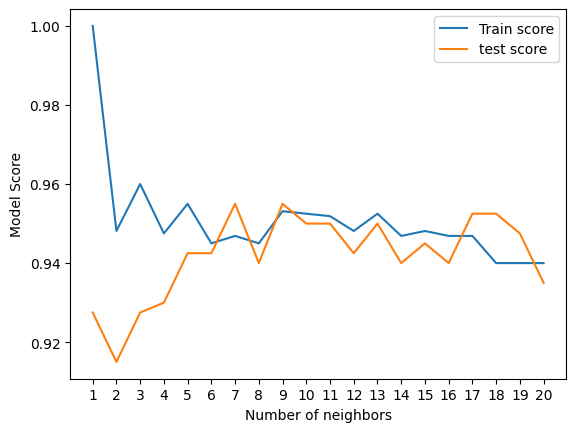

In [ ]:
plt.plot(neighbors,train_scores,label='Train score')   #Draws a line for training accuracy.
plt.plot(neighbors,test_scores,label='test score')    #Draws another line for test accuracy.
plt.xticks(np.arange(1,21,1))
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Model Score')

plt.show()

2) Random and grid search CV

In [ ]:
knn_model.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 20,
 'p': 2,
 'weights': 'uniform'}

In [28]:
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

In [29]:
# RandomSearchCV (CV- cross validation)

knn_rand_grid={
    "n_neighbors" : np.arange(1,21),
    "weights" : ["uniform","distance"],
    "p" : [1,2,1.5],                   #Which combination of parameters makes my KNN model perform the best?"
                                     #So yes, the goal is to find which parameter settings allow the model to predict most accurately on unseen data.
}


In [30]:
np.random.seed(42)
rs_knn = RandomizedSearchCV(KNeighborsClassifier(),
                            param_distributions=knn_rand_grid,    #Means:"The parameters you are allowed to try are stored in knn_rand_grid
                            cv=5,    #Means:For every parameter combination, use 5-fold cross-validation to evaluate it
                            n_iter=20,  #Randomly select and test 20 parameter combinations."
                            verbose=True) #Means:"Show me the progress while running."

#fit the random hyperparameter search model

rs_knn.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'n_neighbors': array([ 1, 2... 18, 19, 20]), 'p': [1, 2, ...], 'weights': ['uniform', 'distance']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``Rando

In [31]:
rs_knn.best_params_

{'weights': 'uniform', 'p': 2, 'n_neighbors': np.int64(11)}

In [ ]:
rs_knn.score(X_test,y_test)

0.95

In [32]:
#GridSearchCV

knn_grid_grid={
    "n_neighbors" : np.arange(1,21),
    "weights": ['uniform','distance'],
    'p':[1,2,0.5]
}

In [34]:
np.random.seed(42)
gs_knn = GridSearchCV(KNeighborsClassifier(),
                            param_grid=knn_grid_grid,    
                            cv=5,    
                              # does not need n_iter because gridsearchcv is a brute force
                            verbose=True)

#fit the random hyperparameter search model

gs_knn.fit(X_train,y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\e

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([ 1, 2... 18, 19, 20]), 'p': [1, 2, ...], 'weights': ['uniform', 'distance']}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_gri

In [ ]:
gs_knn.best_params_

{'n_neighbors': np.int64(11), 'p': 2, 'weights': 'distance'}

In [ ]:
gs_knn.score(X_test,y_test)

0.9525

 1) GridSearchCV finds the best parameters.
 2) Then GridSearchCV automatically creates and trains a KNN model using those best parameters.
 So after fit(), gs_knn is not just storing the parameters. It also contains a trained model called best_estimator_.

# Evaluation

we will see evaluation of some metrics other than accuracy
ROC and AUC --->(for binary classification only)
confusion matrix
precision, recall and F1 score


# Predictions

In [35]:
y_preds=gs_knn.predict(X_test)   #Predict the output values for X_test.  #This line is making predictions using the best trained model.    #"Take the unseen test data (X_test) and predict the output labels.
y_preds                        

array([0, 2, 1, 3, 1, 1, 2, 0, 3, 1, 0, 0, 2, 3, 2, 2, 3, 3, 1, 0, 0, 1,
       1, 2, 0, 1, 3, 2, 2, 0, 0, 0, 3, 0, 1, 1, 2, 0, 3, 0, 2, 2, 2, 0,
       2, 2, 2, 1, 3, 1, 3, 1, 0, 0, 0, 1, 1, 3, 0, 0, 1, 3, 3, 1, 0, 0,
       3, 3, 1, 2, 2, 2, 0, 1, 2, 0, 0, 3, 2, 1, 3, 2, 1, 0, 1, 3, 1, 3,
       3, 0, 3, 3, 2, 1, 3, 2, 2, 3, 1, 1, 0, 0, 1, 0, 0, 3, 2, 0, 1, 1,
       0, 0, 3, 1, 3, 2, 3, 2, 0, 2, 1, 3, 2, 1, 3, 3, 0, 2, 0, 2, 3, 0,
       2, 2, 0, 3, 1, 0, 0, 2, 2, 1, 2, 2, 0, 0, 0, 1, 1, 2, 3, 1, 1, 0,
       2, 2, 0, 1, 0, 2, 2, 3, 3, 2, 1, 0, 1, 2, 2, 3, 3, 0, 1, 0, 3, 1,
       1, 2, 1, 0, 0, 0, 0, 0, 3, 2, 0, 3, 0, 0, 0, 0, 1, 3, 3, 1, 0, 1,
       1, 1, 1, 1, 2, 3, 3, 3, 1, 2, 0, 0, 0, 2, 1, 1, 3, 1, 0, 2, 1, 1,
       3, 2, 3, 0, 0, 2, 1, 3, 0, 1, 2, 0, 2, 3, 2, 0, 1, 3, 3, 0, 1, 3,
       2, 3, 0, 3, 1, 2, 3, 3, 2, 1, 1, 3, 3, 1, 3, 3, 3, 3, 3, 0, 2, 2,
       2, 1, 3, 0, 2, 3, 2, 2, 2, 1, 0, 1, 0, 3, 3, 1, 3, 1, 0, 3, 1, 2,
       0, 0, 3, 0, 1, 2, 3, 3, 3, 1, 1, 0, 1, 3, 3,

In [ ]:
np.array(y_test)       #It converts the output values (y_test) into NumPy array format.

array([0, 2, 1, 3, 1, 1, 2, 0, 3, 1, 0, 0, 2, 3, 3, 2, 3, 3, 1, 0, 0, 2,
       1, 2, 0, 1, 3, 2, 2, 0, 0, 0, 3, 0, 1, 1, 2, 0, 3, 0, 2, 3, 2, 0,
       2, 3, 2, 1, 3, 1, 3, 1, 0, 0, 1, 0, 1, 3, 0, 0, 1, 3, 3, 1, 0, 0,
       3, 3, 1, 2, 2, 2, 0, 1, 2, 0, 1, 3, 2, 2, 3, 2, 1, 0, 1, 3, 1, 3,
       3, 0, 3, 3, 2, 1, 3, 2, 2, 3, 1, 1, 0, 0, 1, 0, 0, 3, 2, 0, 1, 1,
       0, 0, 3, 1, 3, 2, 3, 2, 0, 2, 1, 3, 2, 1, 3, 3, 0, 2, 0, 2, 3, 0,
       2, 2, 0, 3, 1, 0, 0, 2, 2, 1, 3, 2, 0, 0, 0, 1, 1, 2, 3, 1, 1, 0,
       2, 2, 0, 1, 0, 2, 2, 3, 3, 2, 1, 0, 1, 2, 2, 3, 3, 0, 1, 0, 3, 1,
       1, 2, 1, 0, 0, 0, 0, 0, 3, 2, 0, 3, 0, 0, 0, 0, 1, 3, 3, 1, 0, 1,
       1, 1, 1, 2, 2, 3, 3, 3, 1, 2, 0, 0, 0, 2, 1, 1, 3, 1, 0, 2, 1, 1,
       3, 2, 3, 0, 0, 2, 1, 3, 0, 1, 2, 0, 2, 3, 2, 0, 1, 3, 3, 0, 1, 3,
       2, 3, 0, 3, 1, 2, 3, 3, 2, 1, 0, 3, 3, 1, 3, 3, 3, 3, 3, 0, 1, 2,
       2, 2, 3, 0, 2, 3, 2, 2, 2, 1, 0, 2, 0, 3, 3, 1, 3, 1, 0, 3, 1, 2,
       0, 0, 3, 0, 1, 2, 3, 3, 3, 1, 1, 0, 1, 3, 3,

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
#Confusion matrix

sns.set(font_scale=1.5)

def plot_conf_mat(y_test,y_preds):
    # plots a confusion matrix using seaborn's heatmap()
    fig,ax=plt.subplots(figsize=(3,3))
    ax=sns.heatmap(confusion_matrix(y_true= y_test,y_pred=y_preds),  #Creates the confusion matrix
                   annot= True,
                   cbar=False)
    plt.xlabel("True label")
    plt.ylabel("predicted label")

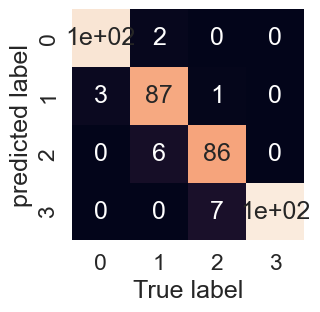

In [ ]:
plot_conf_mat(y_preds=y_preds,y_test= y_test)

here in confusion matrix it is like 87 samples has 1 as a true label and belong to class 1 and also model predicted correctly that is 1 .

next case for 3 samples true label was 0 but model predicted 1 , which is an error by model

and so on samples according to the confusion matrix.......

In [36]:
#Classification report 

from sklearn.metrics import classification_report

In [40]:
print(classification_report(y_test,y_preds))     #classification_report(y_test, y_preds) is a function from scikit-learn that gives a detailed performance report of your classification model.
                                                #Instead of showing only accuracy, it shows:

                                                                            #Precision
                                                                            #Recall
                                                                            #F1-score
                                                                            #Support

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       105
           1       0.92      0.96      0.94        91
           2       0.91      0.93      0.92        92
           3       1.00      0.94      0.97       112

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



Checking best hyperparameter scores

In [41]:
from sklearn.model_selection import cross_val_score

In [ ]:
gs_knn                    #Why is gs_knn written there when gs_knn is already created?

                            #Because cross_val_score() needs to know which model it should evaluate

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([ 1, 2... 18, 19, 20]), 'p': [1, 2, ...], 'weights': ['uniform', 'distance']}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_gri

In [ ]:
cv_accc= cross_val_score(gs_knn,X,y,cv=5,scoring="accuracy")    #a particular metric is checked 5 times with different training testing data combination
cv_accc

Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\e

Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\e

Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\e

Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\e

Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\e

array([0.9375, 0.93  , 0.945 , 0.925 , 0.9075])

 Above  are the accuracies from the 5 different train-test combinations.

QUES- If every time the training data changes, the accuracy changes. Then why calculate it 5 times?

Think of it like an exam:

One test may be easy → score 95.
Another test may be harder → score 85.

Would you judge a student from just one test?

No. You'd give several tests and look at the average performance.

Cross-validation does the same thing for machine learning models.

So the fact that each fold gives a different answer is not a problem—it's actually valuable information. It tells us whether the model is consistently good or whether its performance depends heavily on a particular train-test split.

you can say like ----
"No matter which part of the data is used for testing, the model performs around 93%."

That is much more reliable.

understanding of cv below -
 So a sample that was in the test set in one run will be part of the training set in other runs.
That's why we say cross-validation uses different train-test combinations and gives a more reliable estimate of model performance.

In [46]:
cv_accc.mean()

np.float64(0.9289999999999999)

In [48]:
cv_accc.mean()*100

np.float64(92.89999999999999)

In [49]:
cv_accc= cross_val_score(gs_knn,X,y,cv=5,scoring="precision")   # now different metrics can also be used ,just name it
cv_accc 

Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\e

Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\e

Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\e

Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\e

Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\envs\aienv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\Users\Aishwari-PC\anaconda3\e

array([nan, nan, nan, nan, nan])

You're using a multiclass problem

scoring='precision' works by default only for binary classification. that's why answer is nan nan nan nan nan

For multiclass classification:

cross_val_score(gs_knn, X, y, cv=5, scoring='precision_macro') can be used , similarily for recall and f1 score

## Feature importance
Which features matter the most?

for our problem, it could be something like, which features of a mobile contribute the most to its cost or its price class.

# Saving the model

## > we will be using joblib

In [ ]:
# saving the model with joblib
import joblib

joblib.dump(gs_knn,"Mobile-price-cls-model.joblib" )     # joblib.dump() saves all the information in gs_knn so that gs_knn does not have to be created and trained again
                                                        # saves the current state of the gs_knn object to a  file

['Mobile-price-cls-model.joblib']

## Loading the model

load with the help of 'joblib'

In [51]:
#loading the model with joblib
import joblib

loaded_model = joblib.load("Mobile-price-cls-model.joblib")
loaded_model

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([ 1, 2... 18, 19, 20]), 'p': [1, 2, ...], 'weights': ['uniform', 'distance']}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_gri

joblib.dump() - saves the trained model to a file
loaded_model = joblib.load() - loads/ accesses that saved model back into memory and use it again without retraining

## Testing
### Testing the loaded model with saved model

why do this?
after saving and loading ,can the model still make predictions correctly?
if it can predict, then the save /load process worked 

so testing the loaded model is not training again

In [ ]:
y_gs_knn_preds =gs_knn.predict(X_test)
y_loaded_preds =loaded_model.predict(X_test) #loaded_model = the model that was loaded from the .joblib file

In [ ]:
y_gs_knn_preds == y_loaded_preds      #Compare each prediction from the original model with the corresponding prediction from the loaded model

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [54]:
(y_gs_knn_preds, y_loaded_preds)

(array([0, 2, 1, 3, 1, 1, 2, 0, 3, 1, 0, 0, 2, 3, 2, 2, 3, 3, 1, 0, 0, 1,
        1, 2, 0, 1, 3, 2, 2, 0, 0, 0, 3, 0, 1, 1, 2, 0, 3, 0, 2, 2, 2, 0,
        2, 2, 2, 1, 3, 1, 3, 1, 0, 0, 0, 1, 1, 3, 0, 0, 1, 3, 3, 1, 0, 0,
        3, 3, 1, 2, 2, 2, 0, 1, 2, 0, 0, 3, 2, 1, 3, 2, 1, 0, 1, 3, 1, 3,
        3, 0, 3, 3, 2, 1, 3, 2, 2, 3, 1, 1, 0, 0, 1, 0, 0, 3, 2, 0, 1, 1,
        0, 0, 3, 1, 3, 2, 3, 2, 0, 2, 1, 3, 2, 1, 3, 3, 0, 2, 0, 2, 3, 0,
        2, 2, 0, 3, 1, 0, 0, 2, 2, 1, 2, 2, 0, 0, 0, 1, 1, 2, 3, 1, 1, 0,
        2, 2, 0, 1, 0, 2, 2, 3, 3, 2, 1, 0, 1, 2, 2, 3, 3, 0, 1, 0, 3, 1,
        1, 2, 1, 0, 0, 0, 0, 0, 3, 2, 0, 3, 0, 0, 0, 0, 1, 3, 3, 1, 0, 1,
        1, 1, 1, 1, 2, 3, 3, 3, 1, 2, 0, 0, 0, 2, 1, 1, 3, 1, 0, 2, 1, 1,
        3, 2, 3, 0, 0, 2, 1, 3, 0, 1, 2, 0, 2, 3, 2, 0, 1, 3, 3, 0, 1, 3,
        2, 3, 0, 3, 1, 2, 3, 3, 2, 1, 1, 3, 3, 1, 3, 3, 3, 3, 3, 0, 2, 2,
        2, 1, 3, 0, 2, 3, 2, 2, 2, 1, 0, 1, 0, 3, 3, 1, 3, 1, 0, 3, 1, 2,
        0, 0, 3, 0, 1, 2, 3, 3, 3, 1, 